<a href="https://colab.research.google.com/github/Ayesha-coder317/Portfolio/blob/ComputerVision/ComputerVision_Projecrt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
print("TF Version:", tf.__version__)
print("GPU Available:", len(tf.config.list_physical_devices('GPU')) > 0)


TF Version: 2.19.0
GPU Available: False


In [ ]:
import os, zipfile

zip_path = "/content/drive/MyDrive/DS and AI/ComputerVision/Fruit.v1i.folder.zip"
extract_path = "/content/fruit_dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print("Extracted to:", extract_path)
print("Folders:", os.listdir(extract_path))


Extracted to: /content/fruit_dataset
Folders: ['valid', 'README.roboflow.txt', 'train', 'README.dataset.txt', 'test']


In [ ]:
import os

train_dir = os.path.join(extract_path, "train")
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

print("Classes:", class_names)
print("Number of classes:", len(class_names))


Classes: ['apple', 'avocado', 'banana', 'cherry', 'kiwi', 'mango', 'orange', 'pinenapple', 'strawberries', 'watermelon']
Number of classes: 10


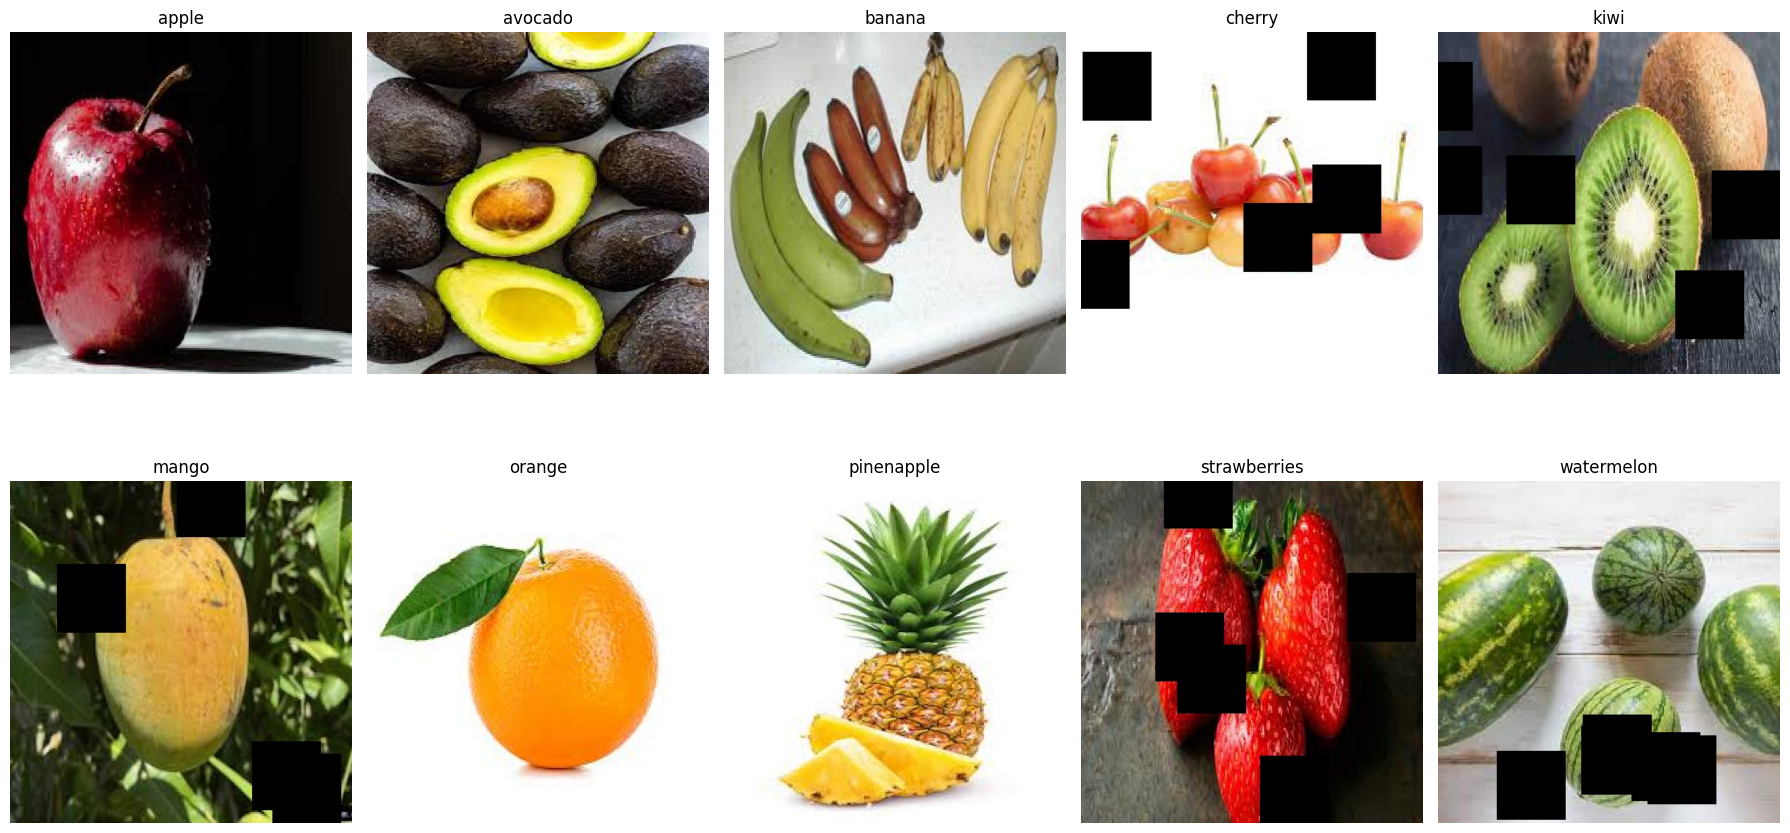

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.figure(figsize=(18, 10))

for i, cls in enumerate(class_names):
    cls_path = os.path.join(train_dir, cls)
    img_name = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_name)

    img = mpimg.imread(img_path)
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()


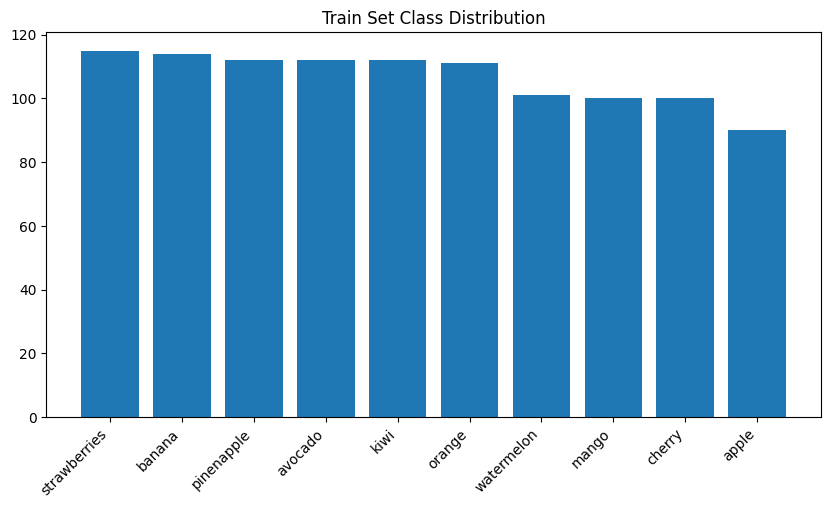

,Class,Count
8,strawberries,115
2,banana,114
7,pinenapple,112
1,avocado,112
4,kiwi,112
6,orange,111
9,watermelon,101
5,mango,100
3,cherry,100
0,apple,90


In [ ]:
import pandas as pd

counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in class_names}
df_counts = pd.DataFrame({"Class": list(counts.keys()), "Count": list(counts.values())}).sort_values("Count", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(df_counts["Class"], df_counts["Count"])
plt.xticks(rotation=45, ha="right")
plt.title("Train Set Class Distribution")
plt.show()

df_counts


# PreProcessing and Data Augmentation


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

valid_dir = os.path.join(extract_path, "valid")
test_dir  = os.path.join(extract_path, "test")

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)


Found 1067 files belonging to 10 classes.
Found 205 files belonging to 10 classes.
Found 102 files belonging to 10 classes.


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.10),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
], name="augmentation")


In [ ]:
rescale = tf.keras.layers.Rescaling(1./255)


# Transfer Learning Model

In [ ]:
from tensorflow.keras import layers, models

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)            # augmentation only affects train-time
x = rescale(x)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x*255.0)  # keep consistent with MobileNetV2
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = models.Model(inputs, outputs)
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)


Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.2189 - loss: 2.3709 - val_accuracy: 0.6878 - val_loss: 1.0445
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 94s 3s/step - accuracy: 0.7027 - loss: 0.9465 - val_accuracy: 0.7854 - val_loss: 0.7063
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.7952 - loss: 0.6556 - val_accuracy: 0.8000 - val_loss: 0.5964
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.8494 - loss: 0.4990 - val_accuracy: 0.8098 - val_loss: 0.5355
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.8655 - loss: 0.4482 - val_accuracy: 0.8293 - val_loss: 0.4746
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - accuracy: 0.8773 - loss: 0.3773 - val_accuracy: 0.8488 - val_loss: 0.4575
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.8990 - loss: 0.3262 - val_accuracy: 0.8634 - val_loss: 0.4334
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.9008 - loss: 0.3010 - val_accuracy: 0.8585 - val_loss:

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)


4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 949ms/step - accuracy: 0.8954 - loss: 0.3665
Test Accuracy: 0.8921568393707275


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import itertools

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true_labels = np.argmax(y_true, axis=1)

y_pred_prob = model.predict(test_ds)
y_pred_labels = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_true_labels, y_pred_labels, target_names=class_names))


4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step
              precision    recall  f1-score   support

       apple       0.77      0.91      0.83        11
     avocado       0.71      1.00      0.83        12
      banana       1.00      0.83      0.91        12
      cherry       1.00      1.00      1.00         6
        kiwi       0.86      0.75      0.80         8
       mango       0.89      0.89      0.89         9
      orange       1.00      0.82      0.90        11
  pinenapple       1.00      1.00      1.00        10
strawberries       0.89      1.00      0.94         8
  watermelon       1.00      0.80      0.89        15

    accuracy                           0.89       102
   macro avg       0.91      0.90      0.90       102
weighted avg       0.91      0.89      0.89       102



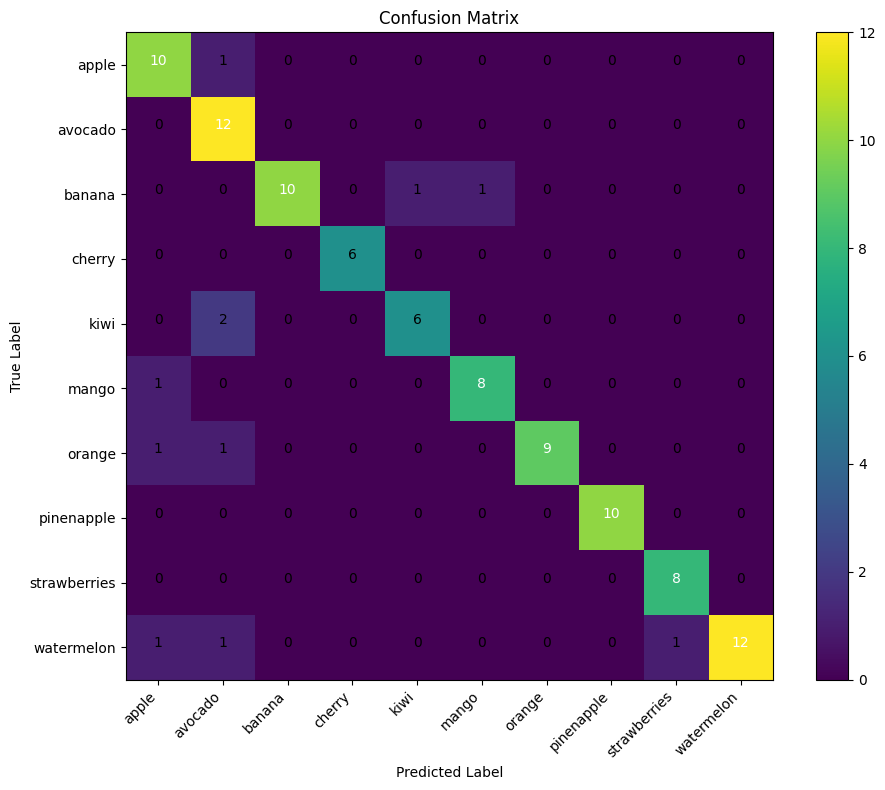

In [ ]:
cm = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(10,8))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j],
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()


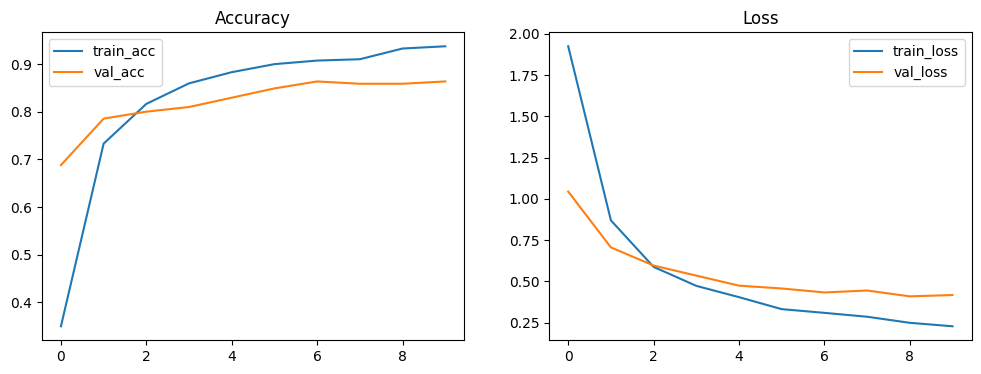

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Loss")
plt.legend()

plt.show()


Total wrong predictions: 11


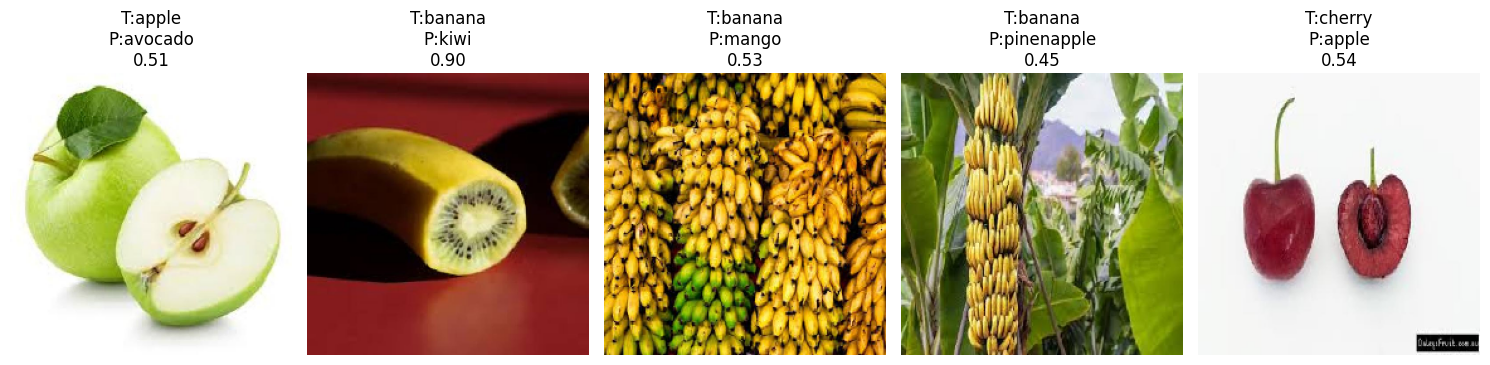

[('/content/fruit_dataset/test/apple/img_1061_jpeg.rf.67f21199fe89dcd13d508f18d0b0de51.jpg',
  'apple',
  'avocado',
  np.float32(0.51221174)),
 ('/content/fruit_dataset/test/banana/img_351_jpeg.rf.bd548e226dbfb681e659fb712e56c2a7.jpg',
  'banana',
  'kiwi',
  np.float32(0.9021941)),
 ('/content/fruit_dataset/test/banana/img_451_jpeg.rf.f2e84cdd1c69f95dddcd10bef2781827.jpg',
  'banana',
  'mango',
  np.float32(0.5335741)),
 ('/content/fruit_dataset/test/banana/img_101_jpeg.rf.21809a09282f09160ff9aa171d91f38f.jpg',
  'banana',
  'pinenapple',
  np.float32(0.45427048)),
 ('/content/fruit_dataset/test/cherry/img_971_jpeg.rf.95e975801707caf5ed214a4941339897.jpg',
  'cherry',
  'apple',
  np.float32(0.5395264))]

In [ ]:
import matplotlib.pyplot as plt

wrong_idx = np.where(y_true_labels != y_pred_labels)[0]
print("Total wrong predictions:", len(wrong_idx))

# show up to 5
show_n = min(5, len(wrong_idx))
indices_to_show = wrong_idx[:show_n]


import glob
all_test_paths = []
for cls in class_names:
    all_test_paths += glob.glob(os.path.join(test_dir, cls, "*"))

def predict_single(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    arr = tf.keras.utils.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    pred = model.predict(arr, verbose=0)[0]
    return np.argmax(pred), np.max(pred)

# find misclassified by scanning (quick, ok for small test sets)
misclassified = []
for p in all_test_paths:
    true_cls = os.path.basename(os.path.dirname(p))
    pred_idx, conf = predict_single(p)
    pred_cls = class_names[pred_idx]
    if pred_cls != true_cls:
        misclassified.append((p, true_cls, pred_cls, conf))
    if len(misclassified) >= 5:
        break

plt.figure(figsize=(15,6))
for i, (p, t, pr, c) in enumerate(misclassified):
    img = tf.keras.utils.load_img(p, target_size=IMG_SIZE)
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(f"T:{t}\nP:{pr}\n{c:.2f}")
    plt.axis("off")
plt.tight_layout()
plt.show()

misclassified


# Deployment

In [ ]:
import numpy as np
import tensorflow as tf

def predict_fruit(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    arr = tf.keras.utils.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)

    probs = model.predict(arr, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_class = class_names[pred_idx]
    confidence = float(np.max(probs))

    print("Predicted:", pred_class)
    print("Confidence:", round(confidence, 4))
    return pred_class, confidence


In [ ]:
# Put an image path from your test set here:
sample_path = all_test_paths[0]
predict_fruit(sample_path)


Predicted: apple
Confidence: 0.8909


('apple', 0.890865683555603)

In [ ]:
import os, zipfile

zip_path = "/content/drive/MyDrive/DS and AI/ComputerVision/Fruit.v1i.folder.zip"
extract_path = "/content/fruit_dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print("✅ Extracted to:", extract_path)
print("Top-level contents:", os.listdir(extract_path))


✅ Extracted to: /content/fruit_dataset
Top-level contents: ['valid', 'README.roboflow.txt', 'train', 'README.dataset.txt', 'test']


In [ ]:
def find_dataset_root(base_path):
    # If base_path already contains train/valid/test
    needed = {"train", "valid", "test"}
    items = set(os.listdir(base_path))
    if needed.issubset(items):
        return base_path

    # Otherwise search one level down
    for name in os.listdir(base_path):
        p = os.path.join(base_path, name)
        if os.path.isdir(p):
            items2 = set(os.listdir(p))
            if needed.issubset(items2):
                return p
    return None

dataset_root = find_dataset_root(extract_path)
print("✅ Dataset root:", dataset_root)
print("Root folders:", os.listdir(dataset_root))


✅ Dataset root: /content/fruit_dataset
Root folders: ['valid', 'README.roboflow.txt', 'train', 'README.dataset.txt', 'test']


# EDA (Classes, Distribution, sample images)

Classes: ['apple', 'avocado', 'banana', 'cherry', 'kiwi', 'mango', 'orange', 'pinenapple', 'strawberries', 'watermelon']
Num classes: 10


,Class,Count
8,strawberries,115
2,banana,114
7,pinenapple,112
1,avocado,112
4,kiwi,112
6,orange,111
9,watermelon,101
5,mango,100
3,cherry,100
0,apple,90


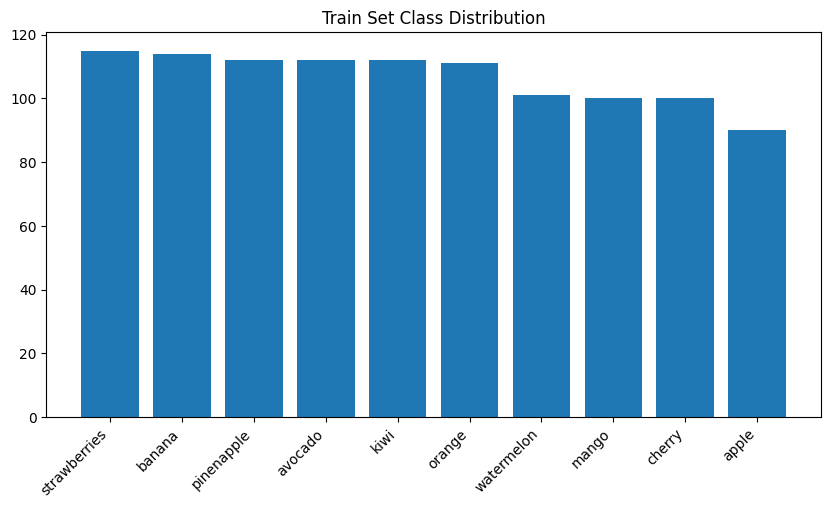

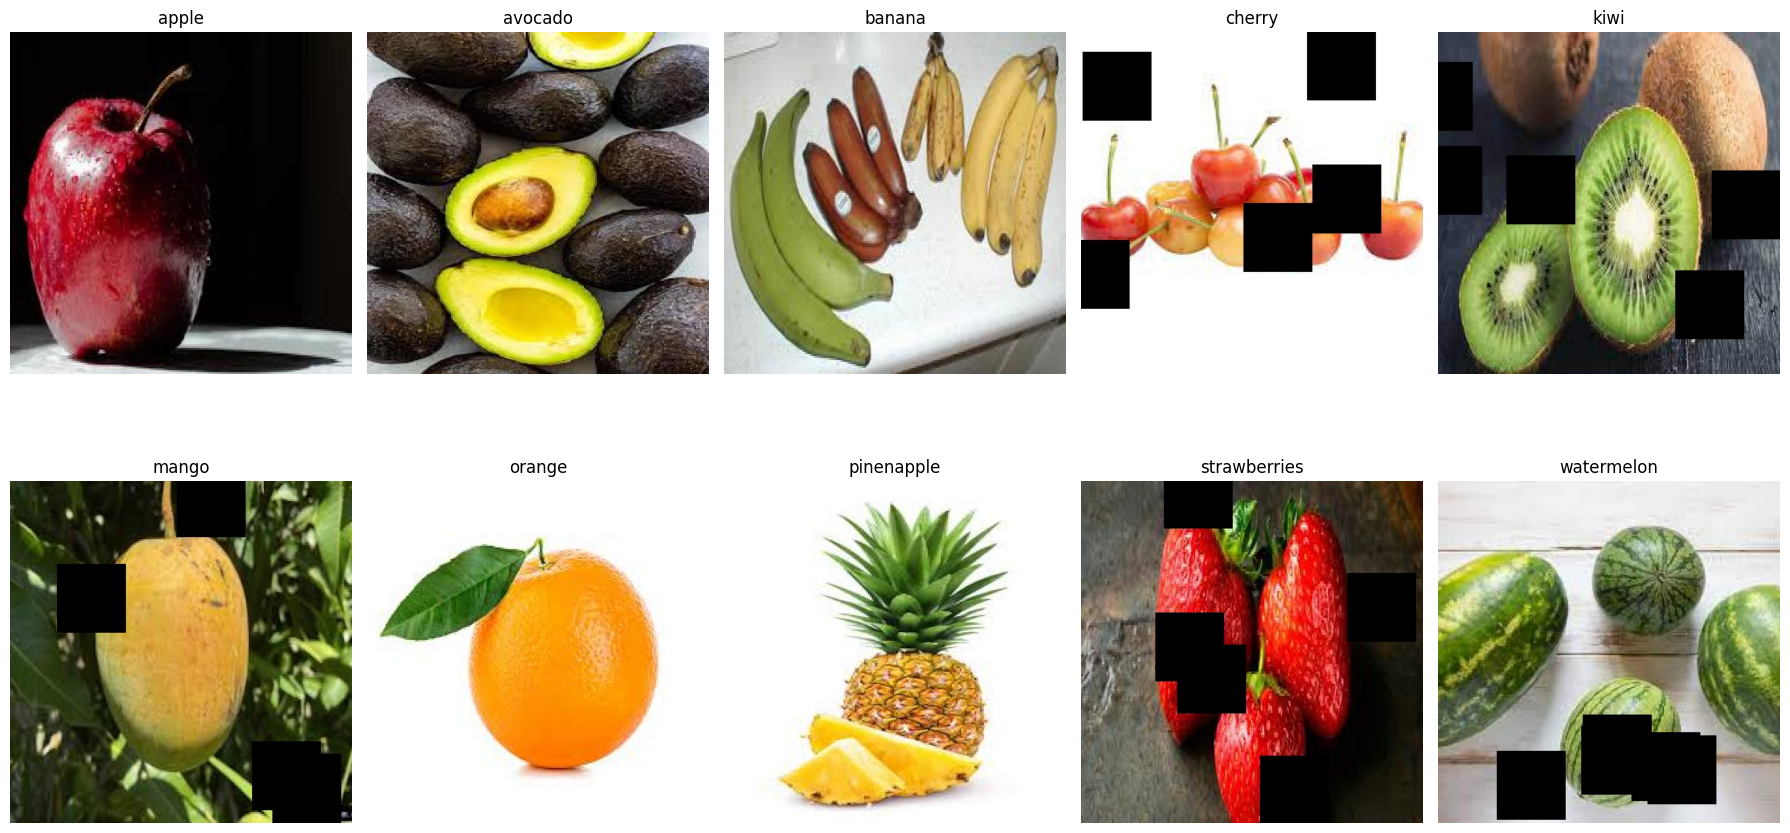

In [ ]:
import os, pandas as pd, matplotlib.pyplot as plt
import matplotlib.image as mpimg

train_dir = os.path.join(dataset_root, "train")
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

print("Classes:", class_names)
print("Num classes:", len(class_names))

# class counts
counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in class_names}
df_counts = pd.DataFrame({"Class": counts.keys(), "Count": counts.values()}).sort_values("Count", ascending=False)
display(df_counts)

plt.figure(figsize=(10,5))
plt.bar(df_counts["Class"], df_counts["Count"])
plt.xticks(rotation=45, ha="right")
plt.title("Train Set Class Distribution")
plt.show()

# sample image per class
plt.figure(figsize=(18, 10))
for i, cls in enumerate(class_names):
    img_name = os.listdir(os.path.join(train_dir, cls))[0]
    img_path = os.path.join(train_dir, cls, img_name)
    img = mpimg.imread(img_path)
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

valid_dir = os.path.join(dataset_root, "valid")
test_dir  = os.path.join(dataset_root, "test")

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.10),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
], name="augmentation")


Found 1067 files belonging to 10 classes.
Found 205 files belonging to 10 classes.
Found 102 files belonging to 10 classes.


In [ ]:
from tensorflow.keras import layers, models

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)  # augmentation applied during training
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)  # expects 0..255 image, will scale to [-1,1]
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = models.Model(inputs, outputs)
model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)


Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.2851 - loss: 2.2527 - val_accuracy: 0.7268 - val_loss: 0.9338
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.6981 - loss: 0.9346 - val_accuracy: 0.8098 - val_loss: 0.6239
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.7930 - loss: 0.6451 - val_accuracy: 0.8293 - val_loss: 0.5249
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.8502 - loss: 0.5146 - val_accuracy: 0.8439 - val_loss: 0.4695
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 92s 3s/step - accuracy: 0.8445 - loss: 0.4494 - val_accuracy: 0.8341 - val_loss: 0.4435
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.8948 - loss: 0.3675 - val_accuracy: 0.8585 - val_loss: 0.4077
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.8919 - loss: 0.3362 - val_accuracy: 0.8293 - val_loss: 0.4343
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.9028 - loss: 0.3111 - val_accuracy: 0.8488 - val_loss

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 911ms/step - accuracy: 0.8558 - loss: 0.4128
Test Loss: 0.3998
Test Accuracy: 0.8529


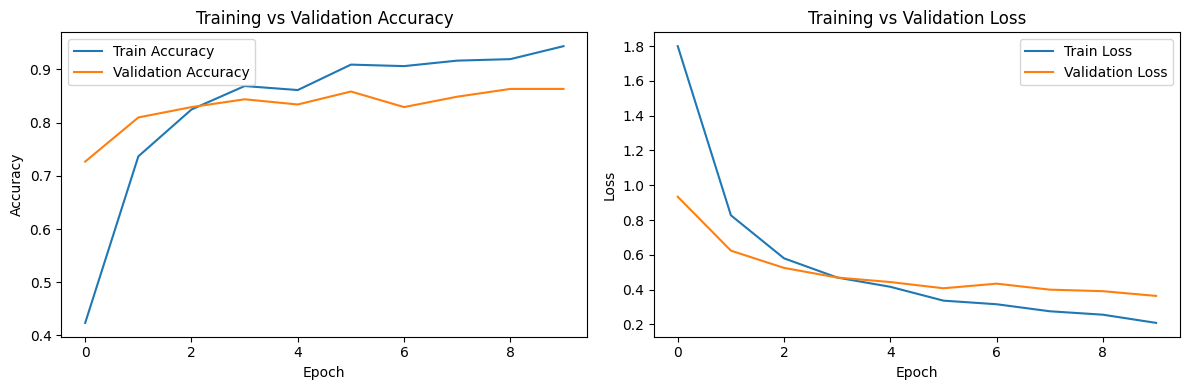

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


# Classification Report


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true_labels = np.argmax(y_true, axis=1)

y_pred_probs = model.predict(test_ds)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

print(classification_report(
    y_true_labels,
    y_pred_labels,
    target_names=class_names
))


4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step
              precision    recall  f1-score   support

       apple       0.62      0.91      0.74        11
     avocado       1.00      1.00      1.00        12
      banana       1.00      0.75      0.86        12
      cherry       0.80      0.67      0.73         6
        kiwi       0.89      1.00      0.94         8
       mango       0.73      0.89      0.80         9
      orange       1.00      0.64      0.78        11
  pinenapple       0.77      1.00      0.87        10
strawberries       0.89      1.00      0.94         8
  watermelon       1.00      0.73      0.85        15

    accuracy                           0.85       102
   macro avg       0.87      0.86      0.85       102
weighted avg       0.88      0.85      0.85       102



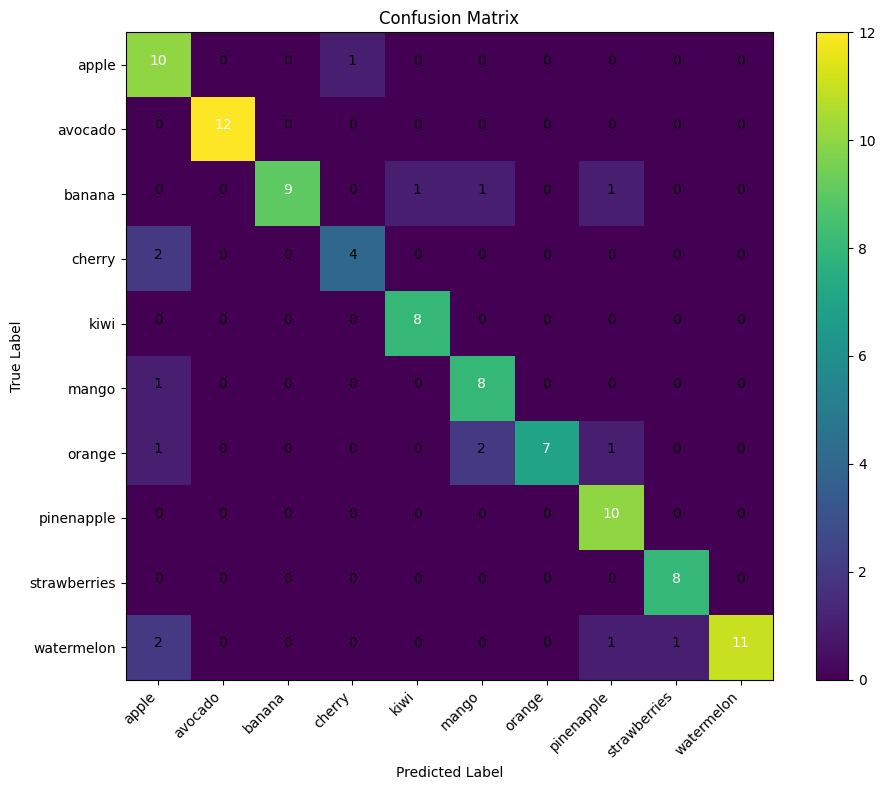

In [ ]:
# Confusion Mtrix

from sklearn.metrics import confusion_matrix
import itertools

cm = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(10,8))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)

thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j],
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


In [ ]:
# Error analysis

import glob
import tensorflow as tf

all_test_images = []
for cls in class_names:
    all_test_images += glob.glob(f"{test_dir}/{cls}/*")

misclassified = []

for img_path in all_test_images:
    true_label = img_path.split("/")[-2]
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)[0]
    pred_label = class_names[np.argmax(pred)]
    confidence = np.max(pred)

    if pred_label != true_label:
        misclassified.append((img_path, true_label, pred_label, confidence))

    if len(misclassified) >= 5:
        break



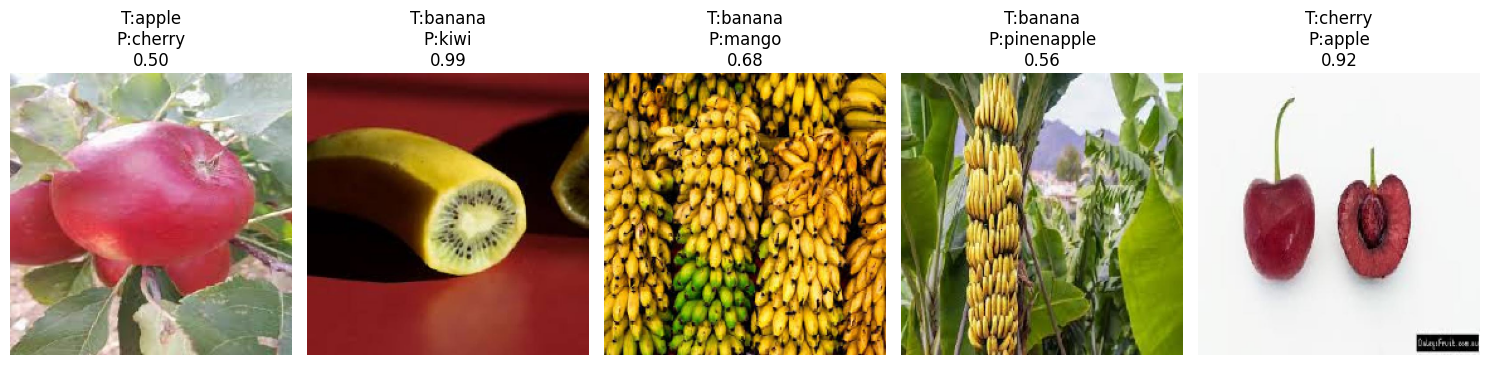

In [ ]:
plt.figure(figsize=(15,4))
for i, (path, true_lbl, pred_lbl, conf) in enumerate(misclassified):
    img = tf.keras.utils.load_img(path, target_size=IMG_SIZE)
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(f"T:{true_lbl}\nP:{pred_lbl}\n{conf:.2f}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
def predict_fruit(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array, verbose=0)[0]
    predicted_class = class_names[np.argmax(preds)]
    confidence = np.max(preds)

    print("Predicted Fruit:", predicted_class)
    print("Confidence:", round(float(confidence), 4))

    return predicted_class, confidence


In [ ]:
predict_fruit(all_test_images[0])


Predicted Fruit: apple
Confidence: 0.7994


('apple', np.float32(0.79943866))